<a href="https://colab.research.google.com/github/JuanRosales707/LAB__16/blob/develop/LAB_!16_CUELLAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

### **a. Realice el preprocesamiento de la información que incluya la corrección de errores, la  imputación de datos faltantes, tratamiento de outliers a nivel univariado y multivariado,  transformación de variables y análisis de correlación entras las variables predictoras.**

In [4]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy import stats
from sklearn.ensemble import IsolationForest

# Cargar el dataset
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets

# Unir las variables independientes y la variable objetivo
df = pd.concat([X, y], axis=1)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Revisar valores únicos y detectar valores problemáticos
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

# Reemplazar los valores '?' por NaN
df.replace('?', np.nan, inplace=True)

age: [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87 89]
workclass: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked' nan]
fnlwgt: [ 77516  83311 215646 ... 173449  89686 350977]
education: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
education-num: [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
marital-status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'

In [6]:
# Ver cuántos datos faltan
print(df.isnull().sum())

# Imputar valores faltantes:
# Para columnas categóricas, usaremos la moda
cat_cols = df.select_dtypes(include='object').columns
imp_mode = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imp_mode.fit_transform(df[cat_cols])

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


In [7]:
# Columnas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Detectar outliers univariados
for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    print(f"{col} - outliers encontrados: {(z_scores > 3).sum()}")

    # Eliminar outliers univariados
    df = df[(z_scores < 3)]

age - outliers encontrados: 186
fnlwgt - outliers encontrados: 505
education-num - outliers encontrados: 315
capital-gain - outliers encontrados: 326
capital-loss - outliers encontrados: 2179
hours-per-week - outliers encontrados: 614


In [8]:
# Aplicar Isolation Forest para detectar outliers multivariados
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[num_cols])

iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(df_scaled)

# Mantener solo los registros no detectados como outliers (-1 son outliers)
df = df[outliers != -1]

In [9]:
# Convertir variables categóricas a numéricas usando LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

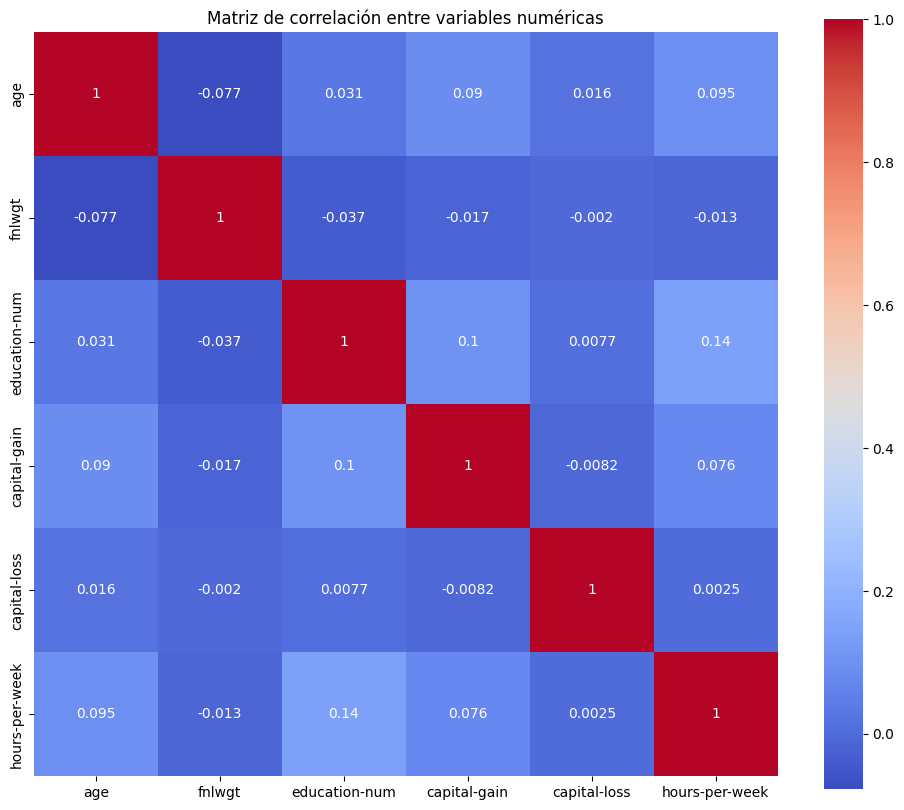

In [10]:
# Matriz de correlación
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', square=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

### **b. Calcule el information value (IV) y seleccione las mejores variables, además, aplique un  escalamiento a las variables numéricas y convierta las variables categóricas a dummies. Separe  los datos en entrenamiento (80%) y prueba (20%) y realice un balanceo de clases.**

In [11]:
# (run this once at the top of the notebook)
!pip install ucimlrepo imbalanced-learn tqdm

from ucimlrepo import fetch_ucirepo
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from collections import defaultdict
from tqdm.auto import tqdm
import warnings; warnings.filterwarnings("ignore")

In [12]:
# Load & minimal cleaning (same as part a, but WITHOUT label‑encoding)
adult = fetch_ucirepo(id=2)
X_raw = adult.data.features.copy()
y_raw = adult.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1).replace("?", np.nan)

# Impute missing values (mode for categoricals, median for numerics)
cat_cols = df.select_dtypes("object").columns
num_cols = df.select_dtypes(["int64", "float64"]).columns

df[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df[cat_cols])
df[num_cols] = SimpleImputer(strategy="median").fit_transform(df[num_cols])

# Target to binary 0/1
target_name = y_raw.columns[0]          # usually "income"
df[target_name] = df[target_name].str.contains(">50K").astype(int)

In [13]:
# Helper to compute WOE & IV for a single feature
def iv_feature(data, feature, target, bins=10, force_categorical=False):
    """
    Returns the IV for a feature.
    If the variable is numeric and not force_categorical, it is binned with qcut().
    """
    x = data[feature]
    y = data[target]

    # Bin numeric variables
    if np.issubdtype(x.dtype, np.number) and not force_categorical:
        try:
            x = pd.qcut(x, q=bins, duplicates='drop')
        except ValueError:              # if too many duplicates
            x = pd.cut(x, bins=bins)

    # WOE / IV table
    iv = 0
    for cat, group in data.groupby(x):
        good = (group[target] == 0).sum()
        bad  = (group[target] == 1).sum()
        # avoid division by zero
        if good == 0 or bad == 0:
            continue
        distr_good = good / (data[target] == 0).sum()
        distr_bad  = bad  / (data[target] == 1).sum()
        woe = np.log(distr_bad / distr_good)
        iv += (distr_bad - distr_good) * woe
    return iv

In [14]:
# Calculate IV for every predictor
iv_dict = {}
print("Computing IV …")
for col in tqdm(df.columns.drop(target_name)):
    iv_dict[col] = iv_feature(df, col, target_name)

iv_df = (pd.Series(iv_dict, name="IV")
           .sort_values(ascending=False)
           .to_frame())

display(iv_df.head(15))

Computing IV …


  0%|          | 0/14 [00:00<?, ?it/s]

,IV
relationship,1.527717
marital-status,1.348677
age,1.076825
education,0.736905
education-num,0.692201
occupation,0.625795
hours-per-week,0.447017
sex,0.300521
workclass,0.132880
native-country,0.074952


In [15]:
# Keep variables with IV >= 0.02  (tweak as needed)
selected_cols = iv_df[iv_df["IV"] >= 0.02].index.tolist()
print(f"Selected {len(selected_cols)} predictors with IV >= 0.02")

X_selected = df[selected_cols]
y = df[target_name]

Selected 11 predictors with IV >= 0.02


In [16]:
# Train–test split  (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
from sklearn.preprocessing import OneHotEncoder

# Nuevo preprocesamiento usando OneHotEncoder (válido para scikit-learn)
preproc = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scaler", StandardScaler())
        ]), num_sel),
        ("cat", Pipeline([
            ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel)
    ],
    remainder="drop"
)

# Aplicar el preprocesador
X_train_pp = preproc.fit_transform(X_train)
X_test_pp  = preproc.transform(X_test)

In [26]:
# Balance the training data with SMOTE
print("y before SMOTE:", np.bincount(y_train.values))
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_pp, y_train)
print("y after  SMOTE:", np.bincount(y_train_bal))

y before SMOTE: [29724  9349]
y after  SMOTE: [29724 29724]


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score # Import roc_auc_score

clf = LogisticRegression(max_iter=1000, n_jobs=-1)
clf.fit(X_train_bal, y_train_bal)

print("Train ROC‑AUC:", roc_auc_score(y_train_bal, clf.predict_proba(X_train_bal)[:,1]))
print("Test  ROC‑AUC:", roc_auc_score(y_test,      clf.predict_proba(X_test_pp)[:,1]))

Train ROC‑AUC: 0.8898038189399263
Test  ROC‑AUC: 0.8804338666803886


### **c. Entrene los modelos k-NN, SVM, regresión logística, árbol de clasificación y Random Forest  utilizando hiperparámetros estándar, búsqueda en cuadrícula y búsqueda aleatoria para poder  encontrar el modelo de clasificación con mejor desempeño. Luego, obtenga el mejor accuracy junto con los hiperparámetros óptimos para dicho modelo.**

In [29]:
# Si no lo hiciste aún, instala imbalanced-learn y scikit-learn (por si falta algo)
!pip install -U scikit-learn imbalanced-learn

# Librerías necesarias
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

In [30]:
# Dataset ya balanceado y preprocesado (X_train_bal, y_train_bal, X_test_pp, y_test)

# Modelos base
models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [31]:
# Hiperparámetros para GridSearch
param_grids = {
    "KNN": {
        "n_neighbors": [3, 5, 7]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10]
    },
    "Decision Tree": {
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20]
    }
}

In [32]:
# Hiperparámetros para RandomizedSearch
param_dists = {
    "KNN": {
        "n_neighbors": range(1, 30)
    },
    "SVM": {
        "C": [0.01, 0.1, 1, 10, 100],
        "kernel": ["linear", "poly", "rbf", "sigmoid"],
        "gamma": ["scale", "auto"]
    },
    "Logistic Regression": {
        "C": np.logspace(-4, 4, 20),
        "solver": ["liblinear", "lbfgs"]
    },
    "Decision Tree": {
        "max_depth": [None] + list(range(2, 20)),
        "min_samples_split": range(2, 10)
    },
    "Random Forest": {
        "n_estimators": [10, 50, 100, 200],
        "max_depth": [None] + list(range(5, 30)),
        "min_samples_split": range(2, 10)
    }
}